# Прогнозирование возрастной категории пользователей по цифровому следу

## Описание задачи

В проекте решается задача многоклассовой классификации: по данным о поведении анонимного пользователя в интернет-сервисах компании «Йети» нужно предсказать его возрастную категорию.

Целевая переменная: `age_category`

- `0` - младше 18 лет;
- `1` - 18-25 лет;
- `2` - 26-40 лет;
- `3` - 41-55 лет;
- `4` - 56+ лет.

Задача важна для возрастного таргетинга рекламы. Особенно критично не завышать возраст несовершеннолетних пользователей, так как это может привести к некорректному показу рекламы и юридическим рискам.

Основная метрика качества: `F1_macro`.
Дополнительно будут отслеживаться `precision_macro` и `recall_macro`.

Целевое качество лучшей модели: `F1_macro >= 0.75` на кросс-валидации и тестовой выборке.

---

## Данные

В проекте используются несколько таблиц:

- `ds_s13_users.csv` - пользователи и целевая возрастная категория;
- `ds_s13_visits.csv` - логи посещений сайтов: дата, время суток, сессия, категория сайта;
- `ads_activity.csv` - активность взаимодействия с рекламой;
- `surf_depth.csv` - глубина переходов по сайтам;
- `primary_device.csv` - основное устройство пользователя;
- `cloud_usage.csv` - использование облачных сервисов.

Главный источник признаков - таблица `visits`, так как она описывает реальные поведенческие паттерны пользователей.

---

## План работы

1. Загрузить данные и проверить их структуру.
2. Объединить все таблицы в единое признаковое пространство.
2. Изучить пропуски, дубликаты, типы данных и распределение классов.
3. Провести EDA:
   - распределение возрастных категорий;
   - активность по времени суток;
   - популярность категорий сайтов;
   - связь возраста с устройством, рекламной активностью, глубиной сёрфинга и облачными сервисами.
4. Сформировать признаки на уровне `user_id`.
6. Разделить данные на train/test по уникальным пользователям со стратификацией по целевой переменной.
7. Настроить пайплайн предобработки без утечки данных.
8. Обучить baseline-модель.
9. Обучить и сравнить `LogisticRegression` и модели `SVC` с разными ядрами.
10. Подобрать гиперпараметры.
11. Провести отбор признаков.
12. Оценить лучшую модель на тестовой выборке.
13. Сохранить модель, пайплайн и функцию подготовки признаков.
14. Проверить, что загруженные артефакты дают те же предсказания.

---

## Потенциальные гипотезы

1. Возрастные группы отличаются по категориям посещаемых сайтов.
2. Время активности связано с возрастом: часть пользователей активнее днём, часть вечером или ночью.
3. Количество сессий, активных дней и средняя активность могут помогать различать возрастные группы.
4. Разнообразие интересов пользователя может быть полезным признаком.
5. Тип устройства, рекламная активность, глубина сёрфинга и использование облачных сервисов дают дополнительный сигнал для классификации.

---

## Планируемые признаки

Из логов посещений будут созданы признаки:

- общее количество посещений;
- количество уникальных сессий;
- количество активных дней;
- среднее число сессий в день;
- среднее число посещений на сессию;
- доли активности по времени суток;
- доли посещений по категориям сайтов;
- количество уникальных категорий сайтов;
- самая частая категория сайта;
- доля самой частой категории;
- показатели разнообразия поведения.

---

## Ожидаемый результат

Итогом проекта станет обученная модель, которая предсказывает возрастную категорию пользователя по его цифровому поведению.

В финале будут представлены:

- сравнительная таблица моделей;
- лучшая модель и её гиперпараметры;
- метрики на кросс-валидации и тестовой выборке;
- выводы о наиболее полезных признаках;
- сохранённые артефакты для внедрения;
- проверка корректности загрузки модели.

## Подготовка среды и библиотек

In [3]:
import numpy as np

from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# 1. Создаем синтетический датасет
X, y = make_regression(
    n_samples=500,
    n_features=5,
    noise=15,
    random_state=42
)

# 2. Модель
model = DecisionTreeRegressor(max_depth=5, random_state=42)

# 3. KFold просто делит данные
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Вариант 1: обычный make_scorer
scorer_wrong = make_scorer(mean_absolute_error)

scores_wrong = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring=scorer_wrong
)

# 5. Вариант 2: правильный sklearn-стиль для MAE
scores_right = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Обычный make_scorer(mean_absolute_error):")
print(scores_wrong)
print("Среднее:", scores_wrong.mean())

print("\nscoring='neg_mean_absolute_error':")
print(scores_right)
print("Среднее:", scores_right.mean())
print("Положительный MAE:", -scores_right.mean())

Обычный make_scorer(mean_absolute_error):
[46.28919953 44.63724154 53.57520878 50.4800714  48.01473658]
Среднее: 48.59929156657278

scoring='neg_mean_absolute_error':
[nan nan nan nan nan]
Среднее: nan
Положительный MAE: nan


/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklea

In [1]:
import pandas as pd


from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, f1_score, recall_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np
import phik
import joblib

In [2]:
rs = 42

In [3]:
!pip freeze > requirements.txt

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [5]:
try:
    users = pd.read_csv('datasets/ds_s13_users.csv')
    visits = pd.read_csv('datasets/ds_s13_visits.csv')
    ads_activity = pd.read_csv('datasets/ads_activity.csv')
    surf_depth = pd.read_csv('datasets/surf_depth.csv')
    primary_device = pd.read_csv('datasets/primary_device.csv')
    cloud_usage = pd.read_csv('datasets/cloud_usage.csv')

except FileNotFoundError as e:
    print(f"Локально файлы не найдены, идем в интернет")
    users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
    visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
    ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
    surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
    primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
    cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

data = {
    'users': users,
    'visits': visits,
    'ads_activity': ads_activity,
    'surf_depth': surf_depth,
    'primary_device': primary_device,
    'cloud_usage': cloud_usage
}

for name, df in data.items():
    print(f'{name}: {df.shape}')

users: (5913, 2)
visits: (1065745, 5)
ads_activity: (5826, 2)
surf_depth: (5715, 2)
primary_device: (5669, 2)
cloud_usage: (5680, 2)


## Проверка дубликатов до объединения таблиц

In [6]:
tables_to_check = {
    'users': users,
    'ads_activity': ads_activity,
    'surf_depth': surf_depth,
    'primary_device': primary_device,
    'cloud_usage': cloud_usage
}

for name, table in tables_to_check.items():
    print(
        f"{name}: full duplicates = {table.duplicated().sum()}, "
        f"duplicated user_id = {table['user_id'].duplicated().sum()}"
    )

users: full duplicates = 87, duplicated user_id = 87
ads_activity: full duplicates = 233, duplicated user_id = 233
surf_depth: full duplicates = 0, duplicated user_id = 0
primary_device: full duplicates = 0, duplicated user_id = 0
cloud_usage: full duplicates = 0, duplicated user_id = 0


удаляем полные дубликаты

In [7]:
users = users.drop_duplicates().reset_index(drop=True)
ads_activity = ads_activity.drop_duplicates().reset_index(drop=True)

Основная таблица пользователей содержит 5913 строк, а таблица посещений значительно больше — 1 065 745 строк, поэтому ключевая часть признаков будет строиться агрегацией поведения на уровне `user_id`.


In [8]:
for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))

========== users ==========


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0
5908,f4bd-a23c0f510067ac3836b6-052bd910,0
5909,eda0-e3e82537c708854dd5f2-ec0540bf,3
5910,e0d8-1b36a6b475ebfbf87c14-fa566d97,0
5911,ad58-7c3c5b76a1dd90ba850d-0307d559,3
5912,c892-72c57d41488d7956d880-3474e42b,2


========== visits ==========


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05
1065740,2025-11-14,утро,672791c6-4f32-4e5a-947a-198a4fd8199a,ffbf-71c28263b860736010d4-a0ee88f3,Category 06
1065741,2025-11-14,утро,67822b34-88ac-40bb-b36a-ab64c3d74333,ffbf-71c28263b860736010d4-a0ee88f3,Category 04
1065742,2025-11-14,утро,98c0ab10-e85f-4c5b-9e41-1171bc118ac5,ffbf-71c28263b860736010d4-a0ee88f3,Category 19
1065743,2025-11-14,утро,9c25daac-741f-4cd3-9dea-31dc187957cd,ffbf-71c28263b860736010d4-a0ee88f3,Category 05
1065744,2025-11-14,утро,f3c9373d-5b8e-499d-b0ad-6f6aa76197bc,ffbf-71c28263b860736010d4-a0ee88f3,Category 10


========== ads_activity ==========


...

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко
5710,b5f3-d23d33e4b2ee506a0f61-809eb9a6,средне
5711,bcc7-aeb86097b4ee8a06cd28-bbd42968,поверхностно
5712,005f-e13485327a8d563dfb3b-ae1fdd6b,поверхностно
5713,15a8-033323dcbda9fc7530dc-16477880,глубоко
5714,0e42-db785d398a348d2da878-0b3d0bcf,поверхностно


========== primary_device ==========


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК
5664,3b93-3b1c8a744d090c17d0d1-ddfbcf51,ПК
5665,30b6-09571dd504e9e809f69f-1adae14e,смартфон
5666,7586-300c84809aabf1c678fa-652cd801,ПК
5667,e3b3-2de04d966dcb5822e628-992de122,смартфон
5668,b1e3-5571e62bad94537087d2-27a044eb,ПК


========== cloud_usage ==========


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False
5675,3bb9-ad6193197ec693e5e508-5bb1399c,True
5676,04a1-7a398d0f4af92e288168-04cfce44,True
5677,38ca-e9f4ad0c70aaf343ed34-4c573d57,False
5678,123c-46f5ce2c7f058cfd3e40-2bcb7c0d,True
5679,b0a1-7f4332342edc93c99d85-06ca847a,True


## аггрегация


In [9]:
def build_user_features(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    df = users.copy()

    df = df.merge(ads_activity, on='user_id', how='left')
    df = df.merge(surf_depth, on='user_id', how='left')
    df = df.merge(primary_device, on='user_id', how='left')
    df = df.merge(cloud_usage, on='user_id', how='left')

    visits_agg = (
        visits
        .groupby('user_id')
        .agg(
            total_visits=('session_id', 'count'),
            unique_categories=('website_category', 'nunique')
        )
        .reset_index()
    )

    daytime_features = (
        pd.crosstab(
            visits['user_id'],
            visits['daytime'],
            normalize='index'
        )
        .add_prefix('daytime_share_')
        .reset_index()
    )

    category_features = (
        pd.crosstab(
            visits['user_id'],
            visits['website_category'],
            normalize='index'
        )
        .add_prefix('category_share_')
        .reset_index()
    )

    visits_features = visits_agg.copy()

    visits_features = visits_features.merge(
        daytime_features,
        on='user_id',
        how='left'
    )

    visits_features = visits_features.merge(
        category_features,
        on='user_id',
        how='left'
    )

    df = df.merge(visits_features, on='user_id', how='left')

    return df


df = build_user_features(
    users,
    visits,
    ads_activity,
    surf_depth,
    primary_device,
    cloud_usage
)

print(df.shape)
df.head()


(5826, 32)


,user_id,age_category,ads_activity,surf_depth,primary_device,cloud_usage,total_visits,unique_categories,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро,category_share_Category 01,category_share_Category 02,category_share_Category 03,category_share_Category 04,category_share_Category 05,category_share_Category 06,category_share_Category 07,category_share_Category 08,category_share_Category 09,category_share_Category 10,category_share_Category 11,category_share_Category 12,category_share_Category 13,category_share_Category 14,category_share_Category 15,category_share_Category 16,category_share_Category 17,category_share_Category 18,category_share_Category 19,category_share_Category 20
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,NaN,глубоко,смартфон,False,192,19,0.333333,0.359375,0.078125,0.229167,0.067708,0.036458,0.036458,0.062500,0.104167,0.020833,0.000000,0.046875,0.098958,0.026042,0.083333,0.015625,0.031250,0.036458,0.052083,0.041667,0.057292,0.067708,0.072917,0.041667
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно,средне,смартфон,False,144,19,0.395833,0.333333,0.090278,0.180556,0.069444,0.041667,0.104167,0.020833,0.055556,0.034722,0.104167,0.104167,0.041667,0.069444,0.041667,0.041667,0.034722,0.000000,0.062500,0.034722,0.041667,0.027778,0.034722,0.034722
2,678b-614cd47d854b9d591db2-000b2e50,0,умеренно,средне,смартфон,False,102,17,0.372549,0.303922,0.127451,0.196078,0.009804,0.068627,0.000000,0.107843,0.068627,0.127451,0.000000,0.039216,0.000000,0.009804,0.029412,0.147059,0.127451,0.009804,0.019608,0.029412,0.019608,0.009804,0.117647,0.058824
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,редко,поверхностно,смартфон,True,253,19,0.260870,0.438735,0.071146,0.229249,0.079051,0.003953,0.102767,0.027668,0.106719,0.047431,0.027668,0.063241,0.059289,0.000000,0.063241,0.015810,0.079051,0.019763,0.027668,0.027668,0.063241,0.138340,0.035573,0.011858
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,очень редко,поверхностно,смартфон,True,122,19,0.418033,0.336066,0.073770,0.172131,0.065574,0.049180,0.090164,0.032787,0.049180,0.008197,0.049180,0.065574,0.073770,0.040984,0.040984,0.122951,0.000000,0.090164,0.024590,0.032787,0.049180,0.032787,0.024590,0.057377


К пользовательской таблице добавлены дополнительные категориальные признаки. Уже на этом этапе видно, что часть значений отсутствует, поэтому в дальнейшем для них потребуется обработка пропусков внутри пайплайна.

In [10]:
col_check = ['daytime', 'website_category']
for col in col_check:
    print(visits[col].value_counts())

daytime
день     389052
вечер    382098
утро     211500
ночь      83095
Name: count, dtype: int64
website_category
Category 03    70260
Category 13    68689
Category 05    60617
Category 06    57110
Category 08    56008
Category 19    55360
Category 07    54683
Category 09    53914
Category 01    53189
Category 10    52818
Category 15    52231
Category 04    51819
Category 20    51105
Category 18    51099
Category 12    50679
Category 17    49878
Category 16    46359
Category 14    46193
Category 02    44478
Category 11    39256
Name: count, dtype: int64


In [11]:
print(visits['date'].min())
print(visits['date'].max())

2025-11-01
2025-11-14


Из логов посещений сформированы поведенческие признаки на уровне пользователя: число визитов, разнообразие категорий, доли посещений по времени суток и доли посещений по категориям сайтов.

## анализ пропусков

In [12]:
summary = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'nunique': df.nunique().values,
        'missing': df.isna().sum().values,
        'missing_share': (df.isna().mean().values).round(3)
    })

display(summary)

,column,dtype,nunique,missing,missing_share
0,user_id,str,5826,0,0.000
1,age_category,int64,5,0,0.000
2,ads_activity,str,5,233,0.040
3,surf_depth,str,3,111,0.019
4,primary_device,str,4,157,0.027
5,cloud_usage,object,2,146,0.025
6,total_visits,int64,363,0,0.000
7,unique_categories,int64,6,0,0.000
8,daytime_share_вечер,float64,2744,0,0.000
9,daytime_share_день,float64,2688,0,0.000


В целевой переменной пропусков нет. Пропуски есть только в дополнительных категориальных признаках: рекламной активности, глубине просмотра, основном устройстве и использовании облака. Их доля небольшая — примерно от 2% до 4%, поэтому их можно обработать заполнением наиболее часто встречающимся значением.

## анализ распределений


In [13]:
def graphics_numerical(column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

In [14]:
def graphics_cat(column):
    print('=' * 100)
    print(f"Признак: {column}")
    print('=' * 100)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print('=' * 100)
    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

In [15]:
df.describe()

,age_category,total_visits,unique_categories,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро,category_share_Category 01,category_share_Category 02,category_share_Category 03,category_share_Category 04,category_share_Category 05,category_share_Category 06,category_share_Category 07,category_share_Category 08,category_share_Category 09,category_share_Category 10,category_share_Category 11,category_share_Category 12,category_share_Category 13,category_share_Category 14,category_share_Category 15,category_share_Category 16,category_share_Category 17,category_share_Category 18,category_share_Category 19,category_share_Category 20
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,2.440439,182.929111,18.472880,0.358154,0.364979,0.078124,0.198743,0.049946,0.041648,0.065570,0.048679,0.057006,0.053731,0.051293,0.052660,0.050902,0.049335,0.036861,0.047751,0.064476,0.043429,0.048661,0.043195,0.046993,0.048015,0.051967,0.047882
std,1.381287,76.390669,0.767831,0.049283,0.045456,0.024757,0.038321,0.031270,0.029450,0.052092,0.027910,0.029430,0.028115,0.029323,0.032273,0.028368,0.028786,0.027077,0.030498,0.057112,0.029839,0.028606,0.028470,0.029178,0.031817,0.028808,0.029157
min,0.000000,100.000000,14.000000,0.215517,0.217822,0.000000,0.049020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,126.000000,18.000000,0.323651,0.335106,0.060811,0.172414,0.026738,0.018692,0.019940,0.029126,0.036697,0.033989,0.029703,0.028846,0.030488,0.029240,0.015957,0.024707,0.008075,0.019802,0.028746,0.021173,0.025424,0.024631,0.030870,0.026524
50%,3.000000,169.000000,19.000000,0.357694,0.365269,0.076271,0.196532,0.048544,0.039450,0.060331,0.046327,0.055298,0.051282,0.049505,0.050633,0.049020,0.047619,0.033725,0.046358,0.057143,0.041176,0.047619,0.040604,0.045137,0.044444,0.050000,0.045455
75%,4.000000,217.000000,19.000000,0.392014,0.395512,0.093567,0.223847,0.069554,0.060864,0.101562,0.066265,0.075676,0.070996,0.069767,0.074366,0.068627,0.067132,0.054264,0.067961,0.103226,0.063213,0.067308,0.060297,0.065185,0.067568,0.070000,0.066938
max,4.000000,853.000000,19.000000,0.532468,0.536364,0.198020,0.356436,0.180723,0.182432,0.259740,0.186275,0.176871,0.174757,0.176471,0.192661,0.190083,0.225490,0.171429,0.177305,0.293919,0.188119,0.205882,0.160000,0.185185,0.206349,0.188119,0.182171


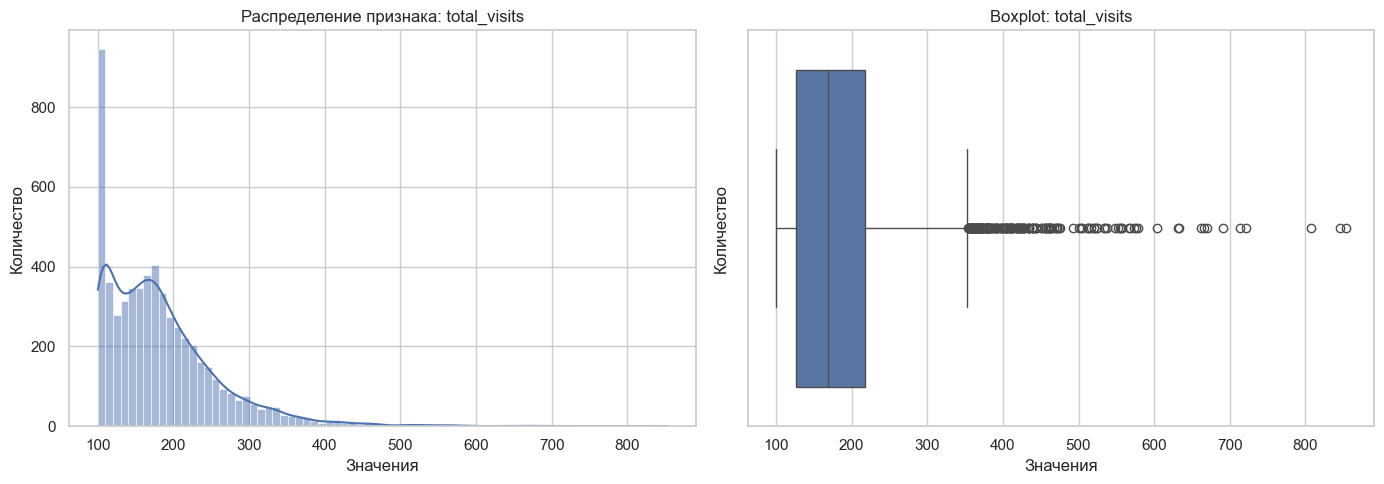

In [16]:
graphics_numerical('total_visits')

Распределение total_visits скошено вправо: у большинства пользователей количество визитов находится примерно в диапазоне 100-250, но есть группа пользователей с заметно более высокой активностью. На boxplot видны многочисленные правые выбросы, однако для поведенческих логов это выглядит естественно: часть пользователей действительно может посещать сайты значительно чаще остальных.

In [17]:
columns_cat = ['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']

Признак: ads_activity


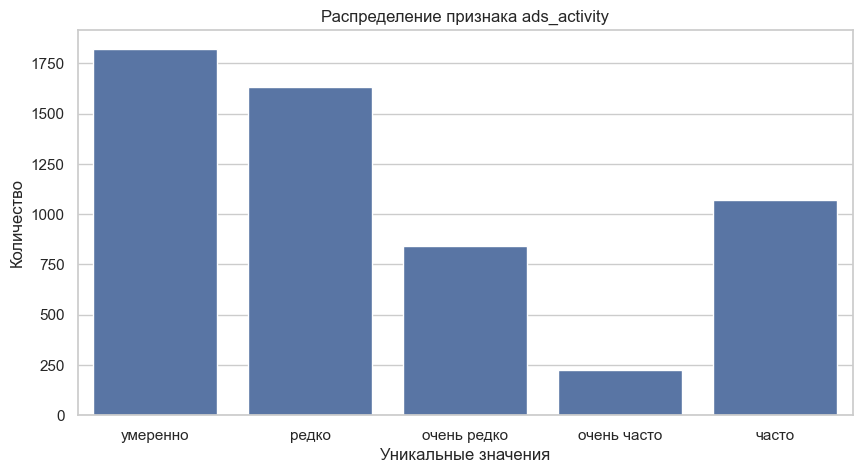

Распределение ads_activity, количество и доля


,Количество,Доля
ads_activity,,
умеренно,1824,0.326122
редко,1634,0.292151
часто,1069,0.191132
очень редко,841,0.150367
NaN,233,NaN
очень часто,225,0.040229


Признак: surf_depth


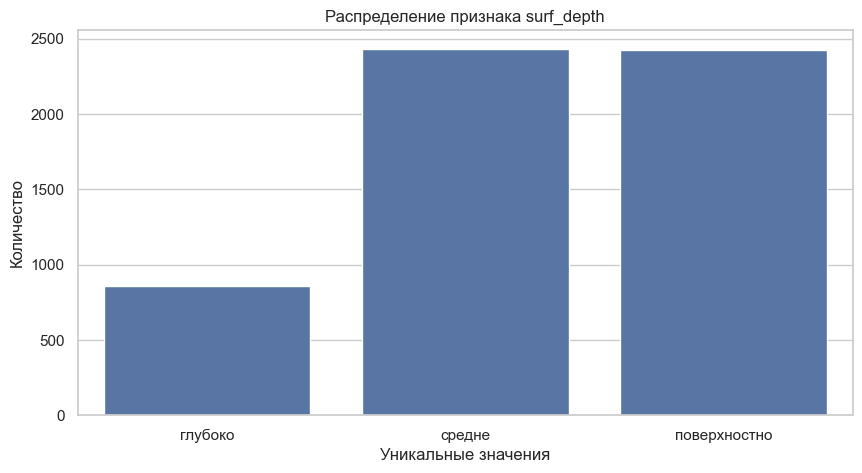

Распределение surf_depth, количество и доля


,Количество,Доля
surf_depth,,
средне,2435,0.426072
поверхностно,2424,0.424147
глубоко,856,0.149781
NaN,111,NaN


In [18]:
for col in columns_cat[:2]:
    graphics_cat(col)

Признак: primary_device


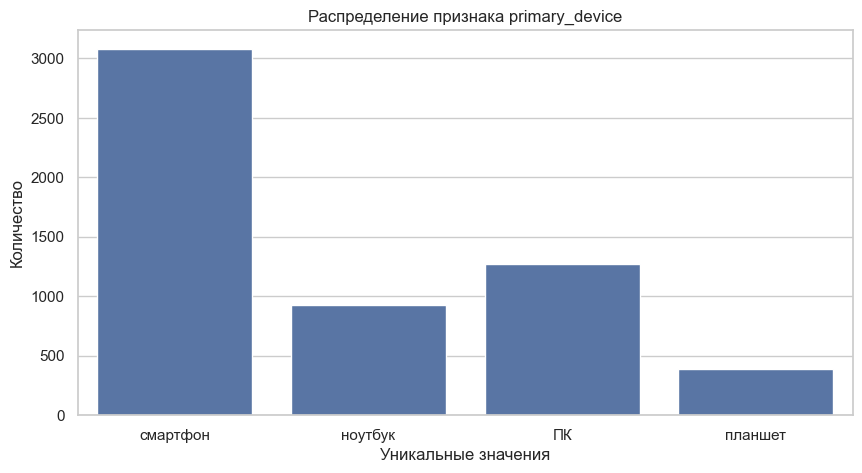

Распределение primary_device, количество и доля


,Количество,Доля
primary_device,,
смартфон,3083,0.543835
ПК,1275,0.224907
ноутбук,923,0.162815
планшет,388,0.068442
NaN,157,NaN


Признак: cloud_usage


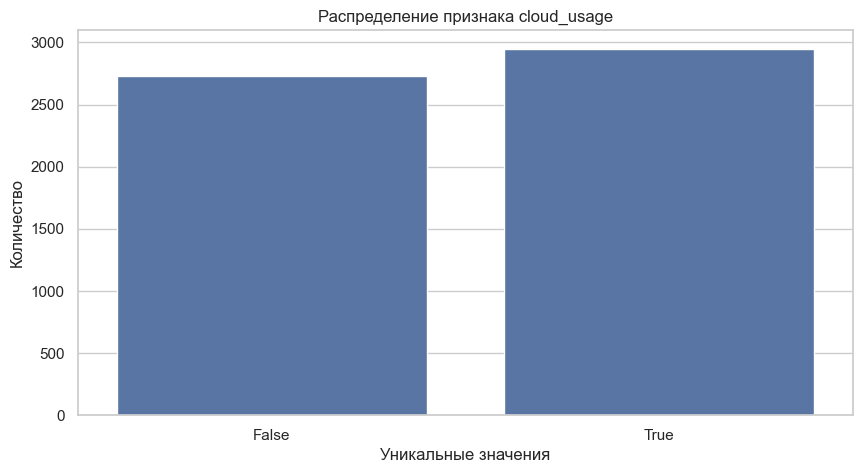

Распределение cloud_usage, количество и доля


,Количество,Доля
cloud_usage,,
True,2951,0.519542
False,2729,0.480458
NaN,146,NaN


In [19]:
for col in columns_cat[2:]:
    graphics_cat(col)

Категориальные признаки имеют достаточно понятные распределения и не содержат экстремально редких основных категорий, кроме значения `очень часто` в `ads_activity`. В `ads_activity` чаще всего встречаются категории `умеренно` и `редко`, а пропуски составляют небольшую отдельную группу, которую лучше обработать на этапе предобработки. В `surf_depth` преобладают значения `средне` и `поверхностно`, категория `глубоко` встречается заметно реже. В `primary_device` основной тип устройства — смартфон, затем идут ПК и ноутбук, планшет встречается редко. Признак `cloud_usage` распределён почти равномерно между `True` и `False`, этот признак имеет малоинформативное распределение, имеет смысл его убрать после проверки коррелляций

Признак: age_category


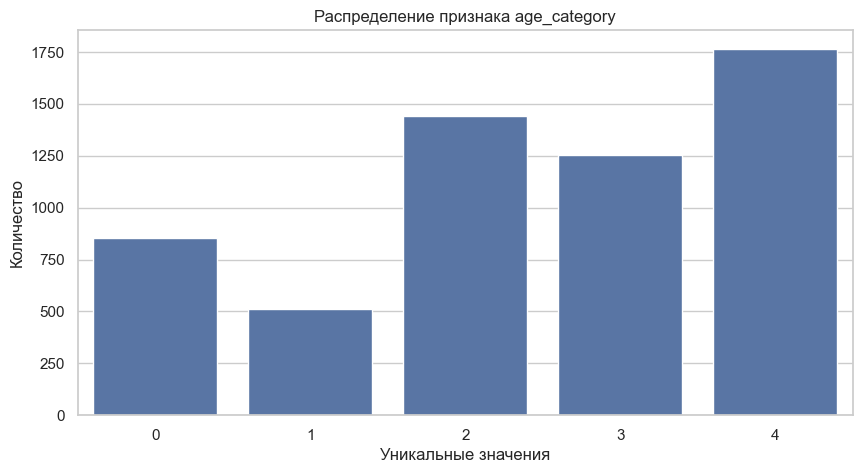

Распределение age_category, количество и доля


,Количество,Доля
age_category,,
4,1766,0.303124
2,1439,0.246996
3,1254,0.215242
0,853,0.146413
1,514,0.088225


In [20]:
graphics_cat('age_category')

Целевая переменная `age_category` распределена неравномерно: чаще всего встречается класс `4`, далее идут классы `2` и `3`, а классы `0` и особенно `1` представлены заметно реже. Это означает, что задача имеет дисбаланс классов, поэтому accuracy не подходит как основная метрика. Для дальнейшей оценки моделей важно использовать `F1_macro`, `precision_macro` и `recall_macro`, а при разбиении данных обязательно применять стратификацию по целевой переменной.


## коррелляционный анализ

In [21]:
X = df.drop(columns='age_category')
y = df['age_category']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=rs,
    stratify=y
)

total_size = df.shape[0]

print('Размеры:')
print(f'Train: {X_train.shape}, {y_train.shape[0]}, доля: {len(y_train) / total_size:.2%}')
print(f'Test: {X_test.shape}, {y_test.shape[0]}, доля: {len(y_test) / total_size:.2%}')


Размеры:
Train: (3495, 31), 3495, доля: 59.99%
Test: (2331, 31), 2331, доля: 40.01%


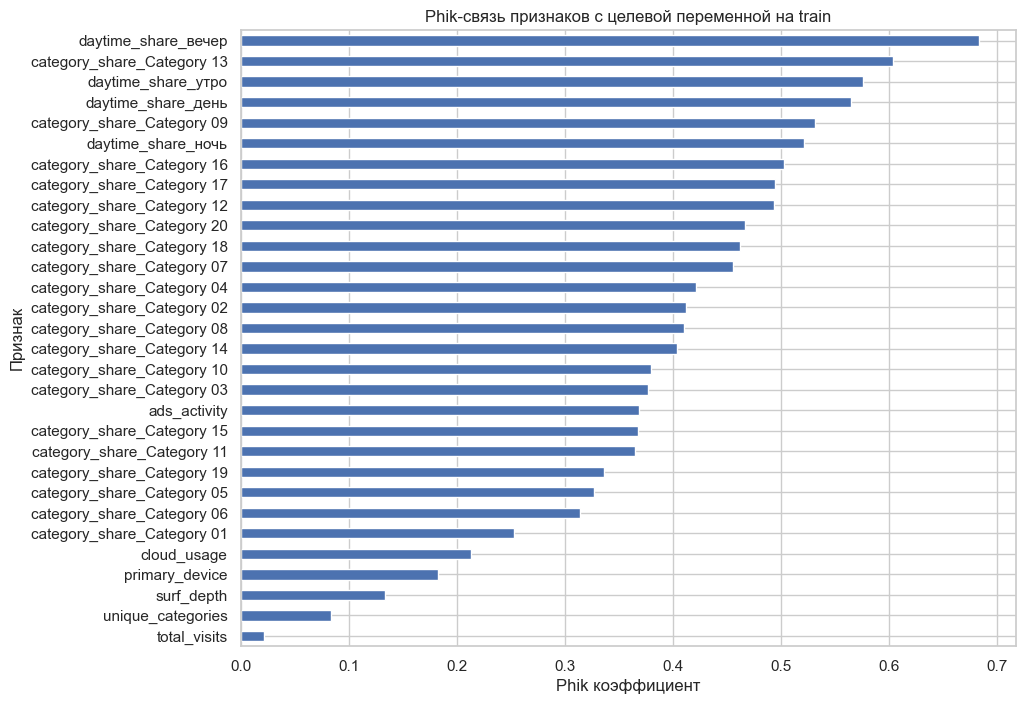

daytime_share_вечер           0.683372
category_share_Category 13    0.603439
daytime_share_утро            0.576232
daytime_share_день            0.565254
category_share_Category 09    0.532002
daytime_share_ночь            0.521247
category_share_Category 16    0.502567
category_share_Category 17    0.494638
category_share_Category 12    0.493227
category_share_Category 20    0.466661
category_share_Category 18    0.461765
category_share_Category 07    0.455874
category_share_Category 04    0.421298
category_share_Category 02    0.411660
category_share_Category 08    0.410063
category_share_Category 14    0.403776
category_share_Category 10    0.379646
category_share_Category 03    0.377352
ads_activity                  0.368973
category_share_Category 15    0.367252
category_share_Category 11    0.365135
category_share_Category 19    0.335824
category_share_Category 05    0.327008
category_share_Category 06    0.313848
category_share_Category 01    0.252693
cloud_usage              

In [23]:
train_for_analysis = X_train.copy()
train_for_analysis['age_category'] = y_train

phik_df = train_for_analysis.drop(columns='user_id')

interval_cols = phik_df.select_dtypes(include='number').columns.drop('age_category')

phik_corr = phik_df.phik_matrix(interval_cols=interval_cols)

target_phik = (
    phik_corr['age_category']
    .drop('age_category')
    .sort_values(ascending=False)
)

target_phik.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Phik-связь признаков с целевой переменной на train')
plt.xlabel('Phik коэффициент')
plt.ylabel('Признак')
plt.show()

display(target_phik)


По PhiK на обучающей выборке наиболее сильная связь с целевой переменной наблюдается у признаков, связанных со временем активности пользователя (`daytime_share_*`) и долями посещений отдельных категорий сайтов (`category_share_*`). Это подтверждает гипотезу, что возрастные группы отличаются по поведенческим паттернам: когда пользователи активны и какие типы сайтов посещают. Дополнительные категориальные признаки (`ads_activity`, `cloud_usage`, `primary_device`, `surf_depth`) имеют более умеренную связь с таргетом. Самые слабые признаки по PhiK — `unique_categories` и `total_visits`, если дальнейший анализ на train подтвердит эту информацию, их имеет смысл удалить.


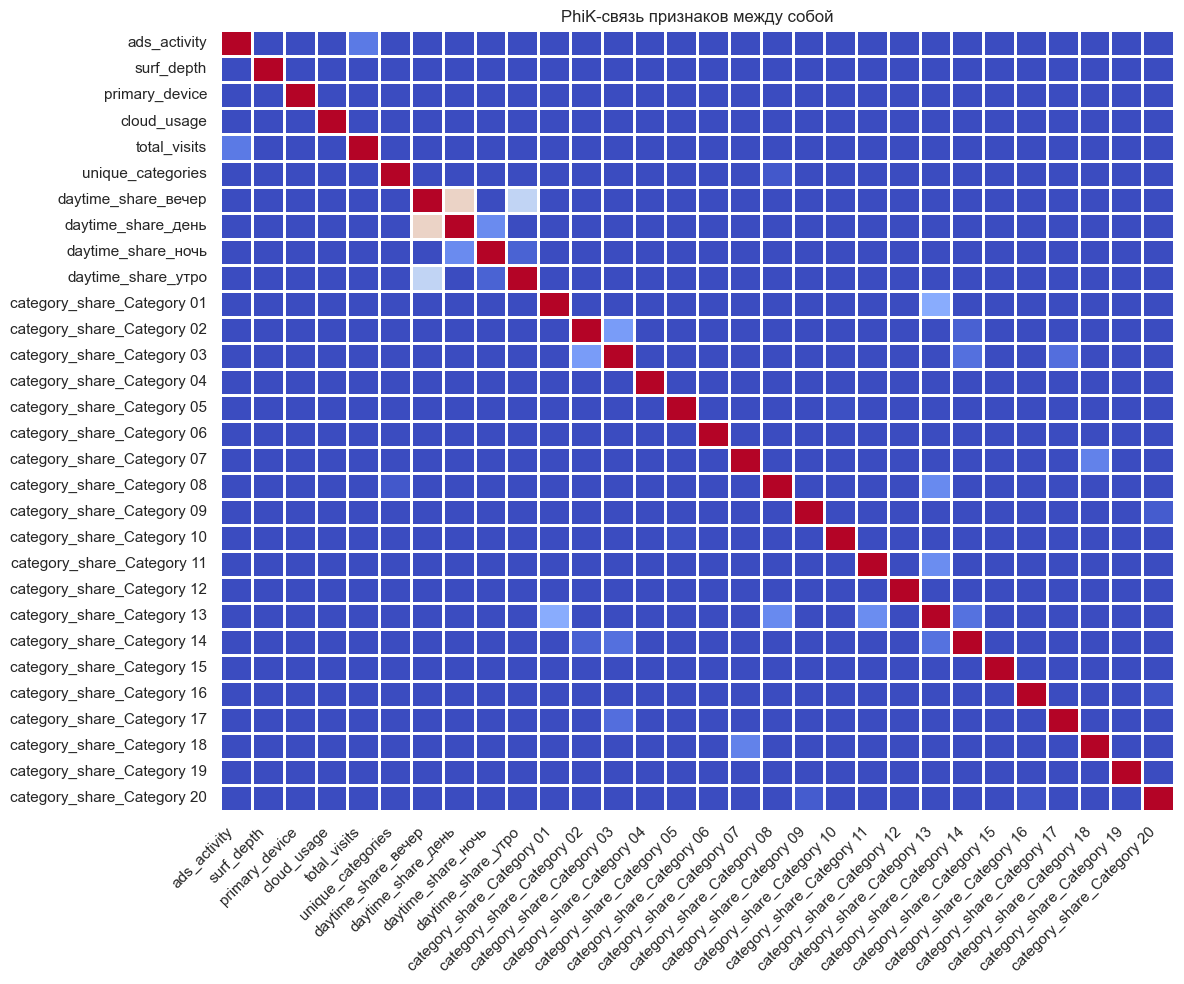

In [24]:
phik_features = phik_corr.drop(index='age_category', columns='age_category')

plt.figure(figsize=(12, 10))

sns.heatmap(
    phik_features,
    cmap='coolwarm',
    vmin=0.3,
    linewidth=1.0,
    cbar=False

)

plt.title('PhiK-связь признаков между собой')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


По PhiK-матрице видно, что большинство признаков между собой связаны слабо, поэтому явной сильной мультиколлинеарности по всей таблице не наблюдается. Наиболее заметные связи есть внутри группы признаков `daytime_share_*`. Также встречаются отдельные умеренные связи между долями некоторых категорий сайтов, но они не выглядят критичными. На этом этапе признаки можно оставить, а окончательное решение об удалении слабых или дублирующих признаков принять после отбора признаков и сравнения качества моделей.

In [25]:
cat_results = []
cat_cols = ['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']

for col in cat_cols:
    table = pd.crosstab(X_train[col], y_train)
    chi2_stat, p_value, dof, expected = chi2_contingency(table)
    cramers_v = association(table, method='cramer')
    cat_results.append({
        'feature': col,
        'chi2': chi2_stat,
        'p_value': p_value,
        'cramers_v': cramers_v,
        'n_categories': X_train[col].nunique()
    })

cat_chi2_result = (
    pd.DataFrame(cat_results)
    .sort_values('cramers_v', ascending=False)
)

display(cat_chi2_result)


,feature,chi2,p_value,cramers_v,n_categories
3,cloud_usage,234.217429,1.631599e-49,0.262118,2
2,primary_device,240.192820,1.512056e-44,0.153545,4
0,ads_activity,297.096167,1.018215e-53,0.148900,5
1,surf_depth,77.446802,1.593923e-13,0.106284,3


Для всех категориальных признаков на обучающей выборке p-value очень мал, значит статистически значимая связь с `age_category` обнаруживается у каждого из них. По силе связи лидирует `cloud_usage`, что соответствует умеренной зависимости. `primary_device`, `ads_activity` и `surf_depth` имеют более слабую, но всё же заметную связь с целевой переменной. Эти признаки стоит оставить для моделирования и позже проверить их вклад на этапе отбора признаков.


In [26]:
def mutual_info(cols, discrete):
    mi_scores = mutual_info_classif(
        X_train[cols],
        y_train,
        discrete_features=discrete,
        random_state=rs
    )

    mi_scores = (
        pd.Series(mi_scores, index=cols)
        .sort_values(ascending=False)
    )

    display(mi_scores)

    return mi_scores

In [27]:
num_cols = (
    X_train
    .select_dtypes(include='number')
    .columns
    .tolist()
)

num_cols


['total_visits',
 'unique_categories',
 'daytime_share_вечер',
 'daytime_share_день',
 'daytime_share_ночь',
 'daytime_share_утро',
 'category_share_Category 01',
 'category_share_Category 02',
 'category_share_Category 03',
 'category_share_Category 04',
 'category_share_Category 05',
 'category_share_Category 06',
 'category_share_Category 07',
 'category_share_Category 08',
 'category_share_Category 09',
 'category_share_Category 10',
 'category_share_Category 11',
 'category_share_Category 12',
 'category_share_Category 13',
 'category_share_Category 14',
 'category_share_Category 15',
 'category_share_Category 16',
 'category_share_Category 17',
 'category_share_Category 18',
 'category_share_Category 19',
 'category_share_Category 20']

In [28]:
mutual_info(num_cols, discrete=False)

daytime_share_вечер           0.255464
daytime_share_утро            0.186825
category_share_Category 09    0.179363
category_share_Category 13    0.178929
daytime_share_ночь            0.170013
category_share_Category 16    0.162586
daytime_share_день            0.156509
category_share_Category 12    0.156149
category_share_Category 17    0.128210
category_share_Category 18    0.125199
category_share_Category 20    0.124677
category_share_Category 07    0.122786
category_share_Category 04    0.120831
category_share_Category 08    0.111940
category_share_Category 10    0.101062
category_share_Category 14    0.100799
category_share_Category 03    0.095482
category_share_Category 02    0.093355
category_share_Category 15    0.084225
total_visits                  0.074285
category_share_Category 11    0.066639
category_share_Category 05    0.066579
category_share_Category 06    0.064956
category_share_Category 19    0.060446
category_share_Category 01    0.044005
unique_categories        

daytime_share_вечер           0.255464
daytime_share_утро            0.186825
category_share_Category 09    0.179363
category_share_Category 13    0.178929
daytime_share_ночь            0.170013
category_share_Category 16    0.162586
daytime_share_день            0.156509
category_share_Category 12    0.156149
category_share_Category 17    0.128210
category_share_Category 18    0.125199
category_share_Category 20    0.124677
category_share_Category 07    0.122786
category_share_Category 04    0.120831
category_share_Category 08    0.111940
category_share_Category 10    0.101062
category_share_Category 14    0.100799
category_share_Category 03    0.095482
category_share_Category 02    0.093355
category_share_Category 15    0.084225
total_visits                  0.074285
category_share_Category 11    0.066639
category_share_Category 05    0.066579
category_share_Category 06    0.064956
category_share_Category 19    0.060446
category_share_Category 01    0.044005
unique_categories        

По mutual information для числовых признаков наиболее полезными выглядят доли посещений отдельных категорий сайтов и признаки активности по времени суток. Это согласуется с результатами PhiK: поведенческие доли несут основной сигнал для предсказания возрастной категории. `total_visits` имеет умеренную информативность, а `unique_categories` стоит удалить.


In [29]:
drop_cols = ['unique_categories', 'user_id']

df_n = df.drop(columns=drop_cols)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()

## пайплайн, dummy модель

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', cat_pipe, cat_cols),
    ],
    remainder='drop'
)

In [31]:
scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro'
}
scores = {}

In [32]:
def evaluate_model(model, model_name):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    scores[model_name] = {
        'f1_macro_mean': cv_result['test_f1_macro'].mean(),
        'recall_macro_mean': cv_result['test_recall_macro'].mean(),
        'precision_macro_mean': cv_result['test_precision_macro'].mean(),
        'f1_macro_std': cv_result['test_f1_macro'].std()
    }

    scores_df = (
        pd.DataFrame(scores)
        .T
        .sort_values(by='f1_macro_mean', ascending=False)
    )

    display(scores_df.round(4))

    return cv_result

In [33]:
dummy_model = DummyClassifier(strategy="stratified", random_state=rs)
dummy = evaluate_model(dummy_model, 'dummy')

,f1_macro_mean,recall_macro_mean,precision_macro_mean,f1_macro_std
dummy,0.1942,0.195,0.1941,0.0118


In [34]:
##новая версия sklearn не поддерживает multi_class добавить в практикуме!
clf_logreg_baseline = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    C=1.0,
    random_state=rs,
    max_iter=1000
)

evaluate_model(clf_logreg_baseline, 'logreg_baseline')

/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and w

,f1_macro_mean,recall_macro_mean,precision_macro_mean,f1_macro_std
logreg_baseline,0.8245,0.8205,0.8311,0.0098
dummy,0.1942,0.1950,0.1941,0.0118


{'fit_time': array([0.02999592, 0.03346419, 0.0776751 , 0.07784104, 0.07326794]),
 'score_time': array([0.00544214, 0.0055089 , 0.00878882, 0.00608015, 0.00584102]),
 'test_f1_macro': array([0.83061915, 0.82924377, 0.81752647, 0.80890119, 0.83597359]),
 'test_recall_macro': array([0.83111653, 0.82391661, 0.81126355, 0.80726038, 0.82878945]),
 'test_precision_macro': array([0.83129894, 0.8373233 , 0.82743388, 0.81127186, 0.84793747])}

Логистическая регрессия значительно превосходит dummy baseline: средний `F1_macro` на кросс-валидации составляет около `0.8245` против `0.1942` у dummy-модели. Значения `recall_macro` и `precision_macro` также находятся около `0.82–0.83`, что говорит о достаточно сбалансированном качестве по классам. Небольшое стандартное отклонение `F1_macro` (`≈ 0.01`) показывает, что результат устойчив на разных фолдах. Модель уже превышает требуемый порог `F1_macro >= 0.75` на кросс-валидации, поэтому её можно использовать как сильную базовую модель для дальнейшего сравнения с SVM и настройкой гиперпараметров.

In [35]:
ovo_svm_baseline = OneVsOneClassifier(
    SVC(random_state=rs),
    n_jobs=-1
)

evaluate_model(ovo_svm_baseline, 'SVC_OvO_baseline')

,f1_macro_mean,recall_macro_mean,precision_macro_mean,f1_macro_std
SVC_OvO_baseline,0.8975,0.8929,0.9041,0.0084
logreg_baseline,0.8245,0.8205,0.8311,0.0098
dummy,0.1942,0.1950,0.1941,0.0118


{'fit_time': array([0.14301205, 0.12859321, 0.15732288, 0.16836619, 0.16113424]),
 'score_time': array([0.28102994, 0.29515076, 0.26623011, 0.27494812, 0.28308392]),
 'test_f1_macro': array([0.89168506, 0.90953014, 0.89459168, 0.88684909, 0.90490988]),
 'test_recall_macro': array([0.89025018, 0.90346404, 0.88633663, 0.88543499, 0.89911856]),
 'test_precision_macro': array([0.8941424 , 0.91792901, 0.906814  , 0.88944493, 0.91238533])}

SVC со стратегией One-vs-One показал лучший результат среди текущих моделей: `F1_macro ≈ 0.8975`, что заметно выше логистической регрессии (`≈ 0.8245`) и dummy baseline (`≈ 0.1942`). Метрики `recall_macro` и `precision_macro` также находятся около `0.89–0.90`, значит модель достаточно ровно работает по разным возрастным категориям. Низкое стандартное отклонение `F1_macro` (`≈ 0.0084`) говорит о стабильности результата на кросс-валидации. На этом этапе SVC OvO выглядит наиболее сильной моделью для дальнейшего подбора гиперпараметров.


In [36]:
def grid_search_model(model, param_grid, model_name):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit='f1_macro',
        cv=cv,
        n_jobs=-1
    )


    grid.fit(X_train, y_train)


    scores[f'{model_name}_grid'] = {
    'f1_macro_mean': grid.cv_results_['mean_test_f1_macro'][grid.best_index_],
    'recall_macro_mean': grid.cv_results_['mean_test_recall_macro'][grid.best_index_],
    'precision_macro_mean': grid.cv_results_['mean_test_precision_macro'][grid.best_index_],
    'f1_macro_std': grid.cv_results_['std_test_f1_macro'][grid.best_index_]
    }


    scores_df = (
        pd.DataFrame(scores)
        .T
        .sort_values(by='f1_macro_mean', ascending=False)
    )

    print(f'Модель: {model_name}')
    print(f'Лучшие параметры: {grid.best_params_}')
    print(f'Лучший F1_macro на GridSearchCV: {grid.best_score_:.4f}')

    display(scores_df.round(4))

    return grid



In [37]:
logreg_params = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs']
}


best_logreg = grid_search_model(
    LogisticRegression(random_state=rs, max_iter=1000),
    logreg_params,
    'logreg'
)

Модель: logreg
Лучшие параметры: {'model__C': 10, 'model__solver': 'lbfgs'}
Лучший F1_macro на GridSearchCV: 0.8245


,f1_macro_mean,recall_macro_mean,precision_macro_mean,f1_macro_std
SVC_OvO_baseline,0.8975,0.8929,0.9041,0.0084
logreg_grid,0.8245,0.8207,0.8309,0.0088
logreg_baseline,0.8245,0.8205,0.8311,0.0098
dummy,0.1942,0.1950,0.1941,0.0118


Подбор гиперпараметра `C` для логистической регрессии выбрал значение `C=10`, однако качество практически не изменилось: `F1_macro` на кросс-валидации осталось около `0.8245`. Это означает, что логистическая регрессия уже на базовых настройках достигает своего текущего уровня качества, а расширение сетки вряд ли даст существенный прирост. По сравнению с SVC OvO логистическая регрессия заметно слабее, поэтому основной кандидат на лучшую модель сейчас — SVC со стратегией One-vs-One.


In [38]:
svc_params = {
    'model__estimator__C': [0.1, 1, 10],
    'model__estimator__kernel': ['linear', 'rbf', 'poly'],
    'model__estimator__gamma': ['scale', 'auto']
}

best_linear_svc = grid_search_model(
    OneVsOneClassifier(
        SVC(random_state=rs),
        n_jobs=-1
    ),
    svc_params,
    'linear_svc_ovo'
)


/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Модель: linear_svc_ovo
Лучшие параметры: {'model__estimator__C': 1, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'rbf'}
Лучший F1_macro на GridSearchCV: 0.8975


,f1_macro_mean,recall_macro_mean,precision_macro_mean,f1_macro_std
SVC_OvO_baseline,0.8975,0.8929,0.9041,0.0084
linear_svc_ovo_grid,0.8975,0.8929,0.9041,0.0084
logreg_grid,0.8245,0.8207,0.8309,0.0088
logreg_baseline,0.8245,0.8205,0.8311,0.0098
dummy,0.1942,0.1950,0.1941,0.0118


Подбор гиперпараметров для SVC OvO выбрал ядро `rbf` с `C=1` и `gamma='scale'`. При этом качество осталось на уровне базовой SVC OvO-модели: `F1_macro ≈ 0.897

F1 macro: 0.8924
Recall macro: 0.8918
Precision macro: 0.8932


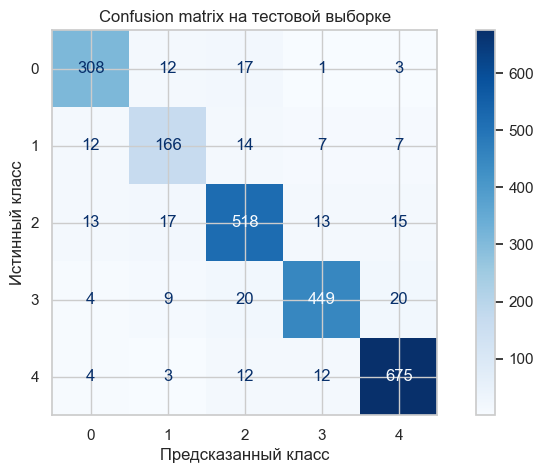

In [39]:
final_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneVsOneClassifier(
        SVC(
        random_state=rs
        ),
        n_jobs=-1
    ))
])

final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)

f1_macro = f1_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
precision_macro = precision_score(y_test, y_pred, average='macro')


print(f'F1 macro: {f1_macro:.4f}')
print(f'Recall macro: {recall_macro:.4f}')
print(f'Precision macro: {precision_macro:.4f}')


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_pipe.classes_
)

disp.plot(cmap='Blues')
plt.title('Confusion matrix на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


На тестовой выборке финальная SVC OvO-модель показала `F1_macro = 0.8924`, `Recall_macro = 0.8918` и `Precision_macro = 0.8932`, что выше требуемого порога `0.75`. По confusion matrix видно, что ошибки распределены относительно равномерно и не указывают на сильный провал по отдельному классу.

In [40]:
import joblib

artifact_path = 'svc_ovo_age_pipeline.joblib'

joblib.dump(final_pipe, artifact_path)

loaded_pipe = joblib.load(artifact_path)

y_pred_loaded = loaded_pipe.predict(X_test)

same_predictions = np.array_equal(y_pred, y_pred_loaded)

print(f'Артефакт сохранён: {artifact_path}')
print(f'Предсказания до и после загрузки совпадают: {same_predictions}')

Артефакт сохранён: svc_ovo_age_pipeline.joblib
Предсказания до и после загрузки совпадают: True


## Выводы о результатах работы

В проекте была решена задача многоклассовой классификации возрастной категории пользователя по его цифровому следу. Были загружены и изучены все предоставленные таблицы, после чего на уровне `user_id` было собрано единое признаковое пространство: использованы данные о рекламной активности, глубине сёрфинга, основном устройстве, использовании облачных сервисов, а также агрегированные признаки из логов посещений сайтов.

Основной вклад в качество модели дали поведенческие признаки из таблицы посещений: доли активности по времени суток и доли посещений разных категорий сайтов. Для обучения использовался безопасный `Pipeline`, включающий заполнение пропусков, кодирование категориальных признаков, масштабирование числовых признаков и классификатор. В качестве baseline была обучена `DummyClassifier`, затем были сравнены `LogisticRegression` и `SVC OvO` с подбором гиперпараметров по `F1_macro`.

Лучшей моделью стала `SVC OvO`. На кросс-валидации она показала `F1_macro ≈ 0.897`, а на тестовой выборке — `F1_macro = 0.8924`, `Recall_macro = 0.8918`, `Precision_macro = 0.8932`. Требуемый порог качества `F1_macro >= 0.75` достигнут как на кросс-валидации, так и на тестовой выборке.

По confusion matrix видно, что большинство объектов каждого возрастного класса расположено на главной диагонали, то есть модель в основном корректно определяет возрастную группу. Ошибки есть во всех классах, но они не выглядят как сильный провал по одной отдельной категории.

Итоговый pipeline был сохранён через `joblib` и затем загружен обратно. Проверка показала, что предсказания до и после загрузки совпадают, значит артефакт модели можно использовать для повторного инференса при условии, что новые данные проходят ту же процедуру сборки признаков.
